In [3]:
import yfinance as yf
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Prix historiques S&P500 sur 1 an
spx = yf.Ticker("^GSPC")
hist = spx.history(period="1y")
prix = hist["Close"]

print(f"Nombre de jours : {len(prix)}")
print(prix.tail()) 

Nombre de jours : 252
Date
2026-03-09 00:00:00-04:00    6795.990234
2026-03-10 00:00:00-04:00    6781.479980
2026-03-11 00:00:00-04:00    6775.799805
2026-03-12 00:00:00-04:00    6672.620117
2026-03-13 00:00:00-04:00    6650.399902
Name: Close, dtype: float64


In [4]:
# Paramètres de l'option
S0 = prix.iloc[0]      # Prix initial du S&P500
K = S0                  # Strike ATM
T = 1                   # Maturité 1 an
r = 0.0375             # Taux sans risque
sigma = 0.25           # Volatilité

# Simulation du delta hedge
dt = 1/252             # Pas de temps quotidien
n = len(prix)          # Nombre de jours

pnl = []
delta_precedent = 0

for i in range(n):
    S = prix.iloc[i]
    t_restant = T - i * dt
    if t_restant <= 0:
        break
    
    # Calcul du delta
    d1 = (np.log(S/K) + (r + sigma**2/2) * t_restant) / (sigma * np.sqrt(t_restant))
    delta = norm.cdf(d1)
    
    # P&L du rebalancement
    if i > 0:
        pnl.append((delta - delta_precedent) * S)
    
    delta_precedent = delta

print(f"P&L total : {sum(pnl):.2f}$")
print(f"P&L moyen par jour : {np.mean(pnl):.2f}$")

P&L total : 2579.73$
P&L moyen par jour : 10.28$


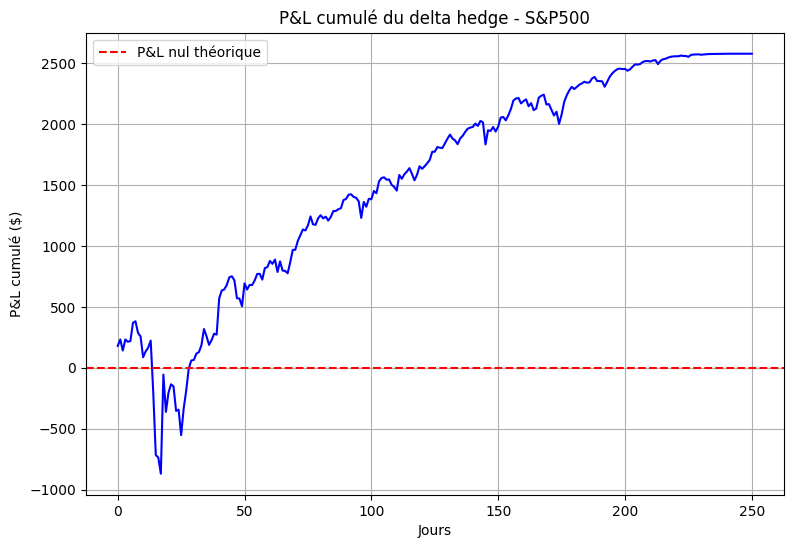

In [5]:
pnl_cumule = np.cumsum(pnl)

plt.figure(figsize=(9, 6))
plt.plot(pnl_cumule, color='blue')
plt.title("P&L cumulé du delta hedge - S&P500")
plt.xlabel("Jours")
plt.ylabel("P&L cumulé ($)")
plt.axhline(y=0, color='red', linestyle='--', label='P&L nul théorique')
plt.legend()
plt.grid(True)
plt.show()

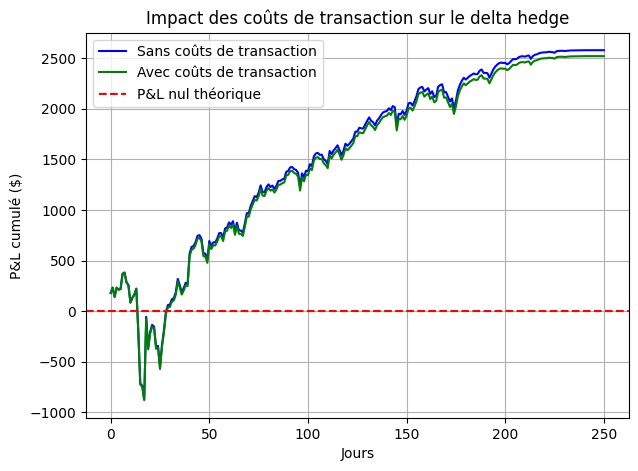

P&L sans coûts : 2579.73$
P&L avec coûts : 2521.09$
Impact des coûts : 58.64$


In [10]:
# Paramètres des coûts de transaction
cout_transaction = 0.005 # 0.5% par transaction

pnl_avec_couts = []
delta_precedent = 0

for i in range(n):
    S = prix.iloc[i]
    t_restant = T - i * dt
    if t_restant <= 0:
        break
    
    # Calcul du delta
    d1 = (np.log(S/K) + (r + sigma**2/2) * t_restant) / (sigma * np.sqrt(t_restant))
    delta = norm.cdf(d1)
    
    # P&L du rebalancement
    if i > 0:
        variation_delta = abs(delta - delta_precedent)
        cout = variation_delta * S * cout_transaction
        pnl_avec_couts.append((delta - delta_precedent) * S - cout)
    
    delta_precedent = delta

# Comparaison avec et sans coûts
pnl_cumule_sans = np.cumsum(pnl)
pnl_cumule_avec = np.cumsum(pnl_avec_couts)

plt.figure(figsize=(7, 5))
plt.plot(pnl_cumule_sans, color='blue', label='Sans coûts de transaction')
plt.plot(pnl_cumule_avec, color='green', label='Avec coûts de transaction')
plt.axhline(y=0, color='red', linestyle='--', label='P&L nul théorique')
plt.title("Impact des coûts de transaction sur le delta hedge")
plt.xlabel("Jours")
plt.ylabel("P&L cumulé ($)")
plt.legend()
plt.grid(True)
plt.show()

print(f"P&L sans coûts : {sum(pnl):.2f}$")
print(f"P&L avec coûts : {sum(pnl_avec_couts):.2f}$")
print(f"Impact des coûts : {sum(pnl) - sum(pnl_avec_couts):.2f}$")

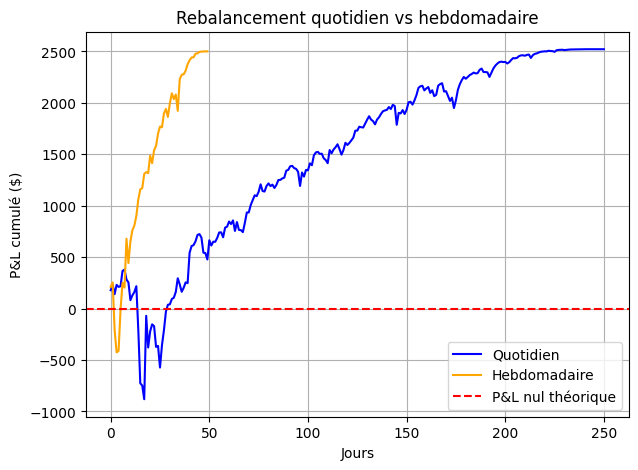

P&L quotidien : 2521.09$
P&L hebdomadaire : 2499.88$


In [16]:
# Comparaison rebalancement quotidien vs hebdomadaire
def delta_hedge(prix, K, T, r, sigma, frequence, cout_transaction=0.005):
    dt = 1/252
    n = len(prix)
    pnl = []
    delta_precedent = 0

    for i in range(n):
        if i % frequence != 0:
            continue
        S = prix.iloc[i]
        t_restant = T - i * dt
        if t_restant <= 0:
            break
        d1 = (np.log(S/K) + (r + sigma**2/2) * t_restant) / (sigma * np.sqrt(t_restant))
        delta = norm.cdf(d1)
        if i > 0:
            variation_delta = abs(delta - delta_precedent)
            cout = variation_delta * S * cout_transaction
            pnl.append((delta - delta_precedent) * S - cout)
        delta_precedent = delta
    return pnl

pnl_quotidien = delta_hedge(prix, K, T, r, sigma, frequence=1)
pnl_hebdo = delta_hedge(prix, K, T, r, sigma, frequence=5)

plt.figure(figsize=(7, 5))
plt.plot(np.cumsum(pnl_quotidien), color='blue', label='Quotidien')
plt.plot(np.cumsum(pnl_hebdo), color='orange', label='Hebdomadaire')
plt.axhline(y=0, color='red', linestyle='--', label='P&L nul théorique')
plt.title("Rebalancement quotidien vs hebdomadaire")
plt.xlabel("Jours")
plt.ylabel("P&L cumulé ($)")
plt.legend()
plt.grid(True)
plt.show()

print(f"P&L quotidien : {sum(pnl_quotidien):.2f}$")
print(f"P&L hebdomadaire : {sum(pnl_hebdo):.2f}$")
